# Computational Graphs in Deep Learning

In deep learning, a **computational graph** is a way to represent a calculation as a graph.

A graph has:

- **nodes**: numbers, tensors, or operations
- **edges**: connections showing how one value is used to compute another

For example, if we define

$$
z = wx + b
$$

then the graph shows that:

- $x$, $w$, and $b$ are inputs
- multiplication computes $wx$
- addition computes $z$

This is useful because deep learning libraries can:

1. evaluate the graph in the **forward pass**
2. apply the chain rule in the **backward pass**
3. compute gradients automatically

In PyTorch, the graph is created dynamically as operations are executed.

In [1]:
import torch

print("PyTorch version:", torch.__version__)

PyTorch version: 2.4.1.post300


## 1. A very small graph

Consider the equation

$$
y = 2x + 1
$$

If $x=3$, then the graph is:

$$
x \rightarrow (2x) \rightarrow (2x+1) = y
$$

More explicitly:

- start with input $x$
- multiply by 2
- add 1
- obtain the output $y$

In [2]:
x = torch.tensor(3.0)
y = 2*x + 1

print("x =", x.item())
print("y =", y.item())

x = 3.0
y = 7.0


This is already a graph, even if we do not draw it visually.

A simple text diagram is:

$x$ --> multiply by 2 --> add 1 --> $y$

## 2. A graph with learnable parameters

In deep learning, we often use parameters such as weights and biases:

$$
z = wx + b
$$

Here:

- $x$ is the input
- $w$ is the weight
- $b$ is the bias
- $z$ is the output

This is the basic building block of a neuron.

In [3]:
x = torch.tensor(4.0)
w = torch.tensor(2.5)
b = torch.tensor(-1.0)

z = w*x + b

print("z =", z.item())

z = 9.0


The corresponding graph is:

- input node: $x$
- parameter node: $w$
- parameter node: $b$
- operation: multiply $w$ and $x$
- operation: add $b$
- output: $z$

## 3. A slightly larger graph: one neuron with a loss

In training, we compare the model prediction with a target value.

Suppose:

$$
\hat{y} = wx + b
$$

and the loss is

$$
L = (\hat{y} - y)^2
$$

This creates a larger graph:

1. compute $\hat{y}=wx+b$
2. compute the error $\hat{y}-y$
3. square the error
4. get the scalar loss $L$

This is a very common pattern in deep learning.

In [4]:
x = torch.tensor(2.0)
y_true = torch.tensor(5.0)

w = torch.tensor(1.5, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)

y_pred = w*x + b
loss = (y_pred - y_true)**2

print("Prediction =", y_pred.item())
print("Loss =", loss.item())

Prediction = 3.5
Loss = 2.25


For this example, the graph is conceptually:

- inputs: $x$, $y$
- parameters: $w$, $b$
- prediction: $\hat{y} = wx+b$
- error: $\hat{y}-y$
- loss: $(\hat{y}-y)^2$

Because `w` and `b` were created with `requires_grad=True`, PyTorch tracks the operations and builds the graph needed for gradient computation. PyTorch autograd supports gradient computation for computational graphs created this way. :contentReference[oaicite:1]{index=1}

## 4. Backward pass on the graph

Once the loss is computed, we can call `.backward()`.

PyTorch then moves backward through the graph and computes derivatives with respect to the parameters.

In [5]:
loss.backward()

print("dL/dw =", w.grad.item())
print("dL/db =", b.grad.item())

dL/dw = -6.0
dL/db = -3.0


This is the key idea of training neural networks:

- the **forward pass** computes the loss
- the **backward pass** computes gradients
- an optimizer uses those gradients to update the parameters

This reverse traversal of the graph is what makes backpropagation practical in deep learning. PyTorch describes autograd as reverse automatic differentiation over the recorded graph. :contentReference[oaicite:2]{index=2}

## 5. Looking inside the graph with `grad_fn`

PyTorch lets us inspect part of the graph.

Each tensor produced by an operation stores a reference to the function that created it, accessible through `.grad_fn`.

In [6]:
x = torch.tensor(2.0)
w = torch.tensor(3.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y_pred = w*x + b
loss = (y_pred - 4.0)**2

print("y_pred =", y_pred)
print("y_pred.grad_fn =", y_pred.grad_fn)

print("loss =", loss)
print("loss.grad_fn =", loss.grad_fn)

y_pred = tensor(7., grad_fn=<AddBackward0>)
y_pred.grad_fn = <AddBackward0 object at 0x767056381120>
loss = tensor(9., grad_fn=<PowBackward0>)
loss.grad_fn = <PowBackward0 object at 0x767056381120>


The exact printed names may vary, but they indicate the operations that created each tensor.

This helps us see that PyTorch is storing the history of the calculation, not just the final number.

## 6. Following the graph backward

We can also inspect previous functions connected to a tensor.

This is not usually needed in everyday work, but it is useful for understanding.

In [7]:
print("loss.grad_fn:", loss.grad_fn)
print("\nNext functions from loss:")
for i, fn in enumerate(loss.grad_fn.next_functions):
    print(f"  {i}: {fn}")

loss.grad_fn: <PowBackward0 object at 0x76705643c190>

Next functions from loss:
  0: (<SubBackward0 object at 0x76719d6feb90>, 0)


This shows that the output tensor is linked to earlier operations in the graph.

So even though the graph is not drawn as a picture, it exists internally as a chain of tensor operations.

## 7. Mini example with two layers

A deep network is just a larger graph.

For example, a two-layer network can be written as

$$
h = W_1 x + b_1
$$

$$
a = \mathrm{ReLU}(h)
$$

$$
\hat{y} = W_2 a + b_2
$$

Each of these steps adds new nodes and edges to the computational graph.

In [8]:
torch.manual_seed(0)

x = torch.tensor([[1.0, 2.0]])

W1 = torch.randn(2, 3, requires_grad=True)
b1 = torch.randn(3, requires_grad=True)

W2 = torch.randn(3, 1, requires_grad=True)
b2 = torch.randn(1, requires_grad=True)

h = x @ W1 + b1
a = torch.relu(h)
y_pred = a @ W2 + b2

print("h =", h)
print("a =", a)
print("y_pred =", y_pred)
print("y_pred.grad_fn =", y_pred.grad_fn)

h = tensor([[ 3.0812, -1.6244, -5.6952]], grad_fn=<AddBackward0>)
a = tensor([[3.0812, 0.0000, 0.0000]], grad_fn=<ReluBackward0>)
y_pred = tensor([[-2.0995]], grad_fn=<AddBackward0>)
y_pred.grad_fn = <AddBackward0 object at 0x76705643c190>


This graph is larger, but the idea is exactly the same:

- matrix multiplication
- addition of biases
- nonlinearity
- another linear transformation
- final output

Deep learning models are large computational graphs with many repeated patterns.

## 8. Why graphs matter

Computational graphs are important because they:

- organize the forward computation
- make gradient computation systematic
- let us train complex models efficiently
- help us reason about model structure

In PyTorch, graphs are created dynamically during execution. In TensorFlow, graph execution can also be used through `tf.function`, where graphs are represented and optimized for execution. :contentReference[oaicite:3]{index=3}

## 9. Simple training loop as repeated graph construction

At each iteration:

1. build the graph during the forward pass
2. compute the loss
3. run backward propagation
4. update the parameters
5. repeat

This is why we can think of training as:\
**build graph -> compute loss -> differentiate -> update**

In [9]:
x_data = torch.tensor([[0.0], [1.0], [2.0], [3.0]])
y_data = torch.tensor([[1.0], [3.0], [5.0], [7.0]])

w = torch.tensor([[0.0]], requires_grad=True)
b = torch.tensor([0.0], requires_grad=True)

lr = 0.1

for epoch in range(10):
    # forward pass: builds the graph
    y_pred = x_data @ w + b
    loss = ((y_pred - y_data)**2).mean()

    # backward pass
    loss.backward()

    # parameter update
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad

    # clear gradients
    w.grad.zero_()
    b.grad.zero_()

    print(f"epoch {epoch:2d} | loss={loss.item():.4f} | w={w.item():.4f} | b={b.item():.4f}")

epoch  0 | loss=21.0000 | w=1.7000 | b=0.8000
epoch  1 | loss=0.5350 | w=1.9700 | b=0.9300
epoch  2 | loss=0.0144 | w=2.0120 | b=0.9530
epoch  3 | loss=0.0010 | w=2.0177 | b=0.9588
epoch  4 | loss=0.0006 | w=2.0177 | b=0.9617
epoch  5 | loss=0.0005 | w=2.0168 | b=0.9641
epoch  6 | loss=0.0005 | w=2.0158 | b=0.9662
epoch  7 | loss=0.0004 | w=2.0149 | b=0.9682
epoch  8 | loss=0.0004 | w=2.0140 | b=0.9701
epoch  9 | loss=0.0003 | w=2.0132 | b=0.9719


## 10. Key ideas to remember

- a computational graph represents a calculation
- nodes are variables or operations
- edges show how values flow through the calculation
- the forward pass computes outputs
- the backward pass computes gradients
- deep neural networks are large computational graphs

## 11. Suggested exercise

For the model

$$
\hat{y} = wx + b
$$

and loss

$$
L = (\hat{y}-y)^2
$$

do the following:

1. draw the graph by hand
2. identify the input, parameters, prediction, error, and loss
3. compute the gradients using PyTorch
4. compare with the analytical derivatives

In [10]:
x = torch.tensor(3.0)
y = torch.tensor(8.0)

w = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(1.0, requires_grad=True)

y_hat = w*x + b
L = (y_hat - y)**2
L.backward()

print("y_hat =", y_hat.item())
print("L =", L.item())
print("dL/dw =", w.grad.item())
print("dL/db =", b.grad.item())

y_hat = 7.0
L = 1.0
dL/dw = -6.0
dL/db = -2.0


## Visualizing one computational graph with `torchviz`

Sometimes students understand computational graphs much better if they can actually **see** the nodes and operations.

Here we will visualize the graph for a very small model:

$$
\hat{y} = wx + b
$$

with loss

$$
L = (\hat{y} - y)^2
$$

The graph will show:

- the input values
- the parameters
- the intermediate operations
- the final loss

To do this, we use `torchviz.make_dot(...)`.

In [12]:
# Install only if needed:
# pip install torchviz graphviz
#
# Also make sure Graphviz itself is installed on your system.
# On Ubuntu/Debian, that is often:
# sudo apt install graphviz

import torch
from torchviz import make_dot

In [13]:
# Small example
x = torch.tensor(2.0)
y = torch.tensor(5.0)

w = torch.tensor(1.5, requires_grad=True)
b = torch.tensor(0.5, requires_grad=True)

y_hat = w * x + b
L = (y_hat - y)**2

print("Prediction =", y_hat.item())
print("Loss =", L.item())

Prediction = 3.5
Loss = 2.25


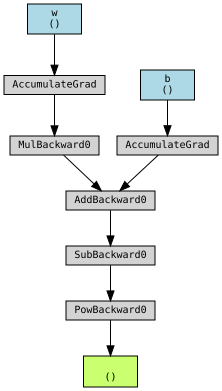

In [14]:
# Build and display the graph
dot = make_dot(L, params={"w": w, "b": b})
dot

In the displayed graph, students should identify:

- the **parameters**: $w$ and $b$
- the **prediction**: $\hat{y} = wx+b$
- the **error**: $\hat{y}-y$
- the **loss**: $L = (\hat{y}-y)^2$

The graph is read from the inputs and parameters toward the final output.

Then, during backpropagation, PyTorch traverses this graph in the reverse direction to compute gradients.

In [15]:
dot.format = "png"
dot.render("simple_computational_graph", cleanup=True)
print("Saved graph as simple_computational_graph.png")

Saved graph as simple_computational_graph.png
